# 12. 改进的遮蔽攻击对抗性训练

## 12.0 主要内容介绍
在实验11中，我们实现了基于固定top_k的遮蔽攻击及其对抗性训练。但存在以下问题：
1. 遮蔽攻击强度过大（top_k=9, kernel_size=3），导致数字语义被完全破坏
2. 实验结果与论文结论存在矛盾（PGD-AT对遮蔽攻击的防御效果不应优于标准训练）

本实验引入**自适应遮蔽攻击（AdaptiveOcclusionAttack）**，参考论文中inductiveOcclusionAttack的逻辑：
- 渐进式增加遮蔽区域数量(N)和半径(R)
- 逐样本早停：攻击成功即停止遮蔽，使用最小遮蔽量
- 保留数字的语义可辨识性

本实验还增加了：
- 攻击预测结果展示（模型将对抗样本预测为哪个数字）
- 迁移攻击语义分析
- PGD-AT与标准模型的对比分析

## 12.1 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from occlusion_attack import OcclusionAttack, AdaptiveOcclusionAttack
from adversarial_training import AdaptiveOcclusionAdversarialTraining
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

d:\anaconda3\envs\adv-attack\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 12.2 自适应遮蔽攻击（Adaptive Occlusion Attack）在MNIST上的实现
与实验11中固定top_k的遮蔽攻击不同，自适应遮蔽攻击：
1. 使用梯度积分计算每个像素的重要性
2. 按重要性排序，找到最重要的N个像素中心
3. **渐进式**增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
4. **逐样本早停**：一旦模型预测改变（攻击成功），立即停止该样本的遮蔽

这样确保使用最小遮蔽量，保留数字的语义可辨识性。

### 12.2.1 加载标准模型并测试自适应遮蔽攻击效果

In [2]:
# 加载标准训练的LeNet5模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

print('标准LeNet5模型加载完成')

C:\Users\31198\AppData\Local\Temp\ipykernel_77784\3247200306.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  std_state = torch.load('./save_model/50epoch/mnist_lenet5.pt

标准LeNet5模型加载完成


In [3]:
# 加载MNIST测试集
imgs, lbls = load_mnist_test()

# 测试标准模型在干净样本上的准确率
cln_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {cln_acc:.2f}%')

 77784 20260403 22:49:56 标准模型 - 干净样本准确率: 99.00%


In [4]:
# 自适应遮蔽攻击参数
N = 5       # 最大遮蔽区域数量
R = 3       # 最大遮蔽半径
C_COLOR = 0.0  # 遮蔽颜色（黑色）

# 测试自适应遮蔽攻击对标准模型的效果
adaptive_occlusion = AdaptiveOcclusionAttack(std_lenet, N=N, R=R, c=C_COLOR)
adaptive_occ_acc, adaptive_occ_preds = test_fn(nn.Sequential(adaptive_occlusion, std_lenet), imgs, lbls, bs=250, mode='attack')
logger.info(f'标准模型 - 自适应遮蔽攻击后准确率: {adaptive_occ_acc:.2f}%')

# 对比：原始固定遮蔽攻击
occlusion_fixed = OcclusionAttack(std_lenet, top_k=9, occlu_color=0.0, kernel_size=3)
fixed_occ_acc, fixed_occ_preds = test_fn(nn.Sequential(occlusion_fixed, std_lenet), imgs, lbls, bs=250, mode='attack')
logger.info(f'标准模型 - 固定遮蔽攻击后准确率: {fixed_occ_acc:.2f}%')

print(f'\n对比: 自适应遮蔽攻击准确率={adaptive_occ_acc:.2f}% vs 固定遮蔽攻击准确率={fixed_occ_acc:.2f}%')
print('自适应攻击使用更少的遮蔽，数字语义更清晰')

 77784 20260403 22:50:16 标准模型 - 自适应遮蔽攻击后准确率: 16.66%
 77784 20260403 22:50:23 标准模型 - 固定遮蔽攻击后准确率: 28.64%



对比: 自适应遮蔽攻击准确率=16.66% vs 固定遮蔽攻击准确率=28.64%
自适应攻击使用更少的遮蔽，数字语义更清晰


### 12.2.2 可视化自适应遮蔽攻击效果（含模型预测标签）

=== 自适应遮蔽攻击 vs 固定遮蔽攻击 对比 ===

--- 数字 1 ---


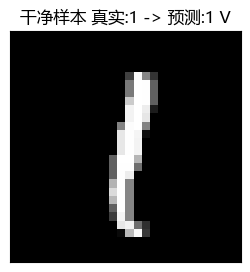

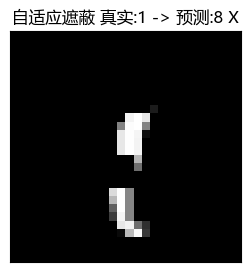

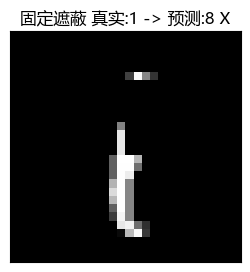


--- 数字 4 ---


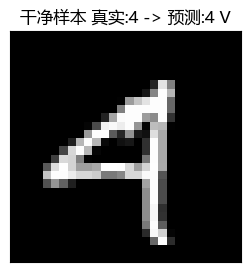

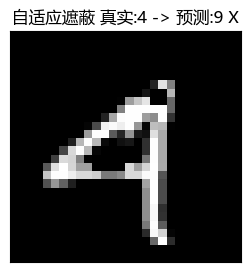

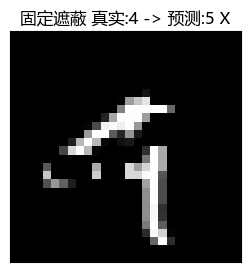


--- 数字 3 ---


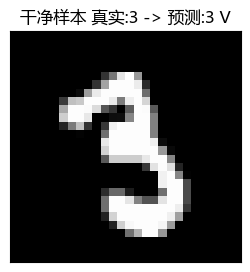

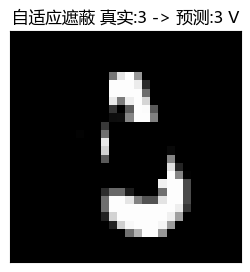

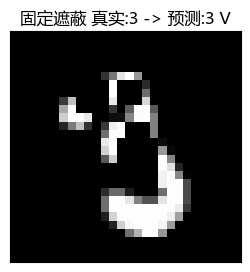


--- 数字 6 ---


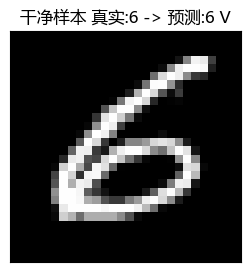

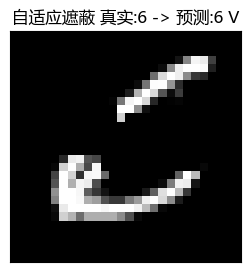

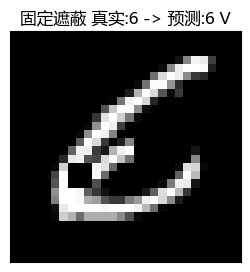


--- 数字 2 ---


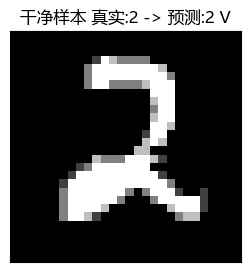

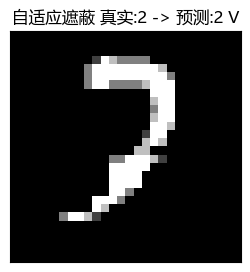

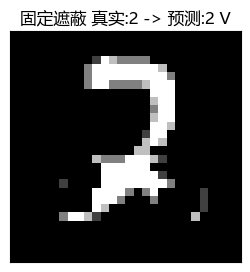


--- 数字 7 ---


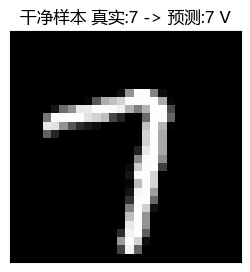

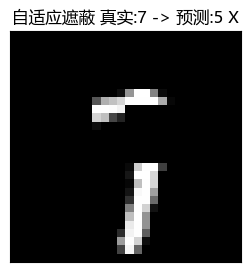

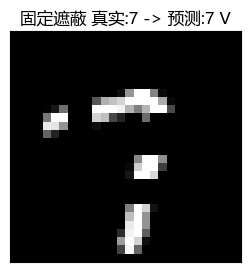


--- 数字 0 ---


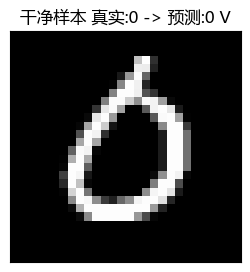

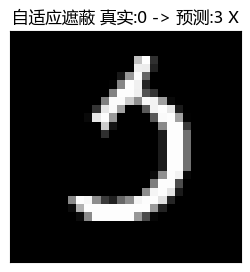

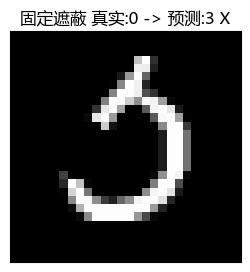


--- 数字 8 ---


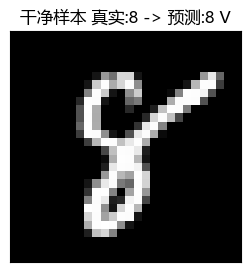

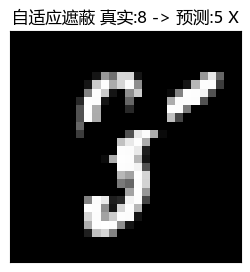

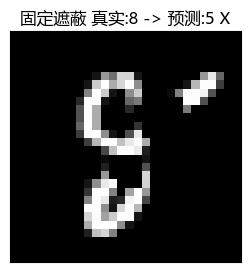


--- 数字 5 ---


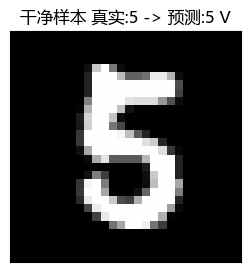

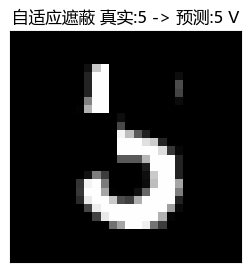

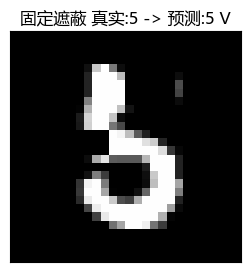


--- 数字 9 ---


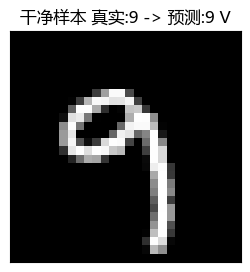

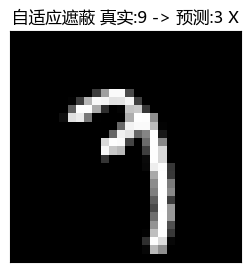

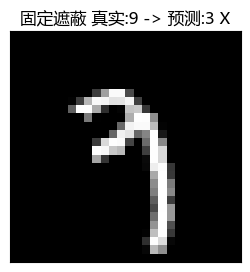

In [5]:
def imshow_mnist_with_pred(img, model, true_label, title_prefix=''):
    """显示MNIST图像并标注模型预测结果"""
    npimg = img.cpu().squeeze().numpy()
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    plt.figure(figsize=(3, 3))
    plt.imshow(npimg, cmap='gray')
    correct_str = 'V' if pred == true_label else 'X'
    plt.title(f'{title_prefix} 真实:{true_label} -> 预测:{pred} {correct_str}')
    plt.xticks([])
    plt.yticks([])
    plt.show()

# 取一个batch进行可视化
sample_x = imgs[:250].to(device)
sample_y = lbls[:250].to(device)
std_lenet.eval()

# 自适应遮蔽攻击
sample_adv_adaptive = adaptive_occlusion((sample_x, sample_y))
# 固定遮蔽攻击（对比用）
sample_adv_fixed = occlusion_fixed((sample_x, sample_y))

# 找到0-9每个数字的第一个样本
shown_labels = set()
selected_indices = []
for i in range(sample_y.shape[0]):
    label = int(sample_y[i].item())
    if label not in shown_labels:
        shown_labels.add(label)
        selected_indices.append(i)
    if len(shown_labels) == 10:
        break

print('=== 自适应遮蔽攻击 vs 固定遮蔽攻击 对比 ===')
for idx in selected_indices:
    label = int(sample_y[idx].item())
    print(f'\n--- 数字 {label} ---')
    imshow_mnist_with_pred(sample_x[idx], std_lenet, label, '干净样本')
    imshow_mnist_with_pred(sample_adv_adaptive[idx], std_lenet, label, '自适应遮蔽')
    imshow_mnist_with_pred(sample_adv_fixed[idx], std_lenet, label, '固定遮蔽')

### 12.2.3 攻击预测分析（各数字类别的预测分布）

In [6]:
def attack_prediction_analysis(true_labels, predictions, attack_name):
    """分析攻击后每个真实类别的预测分布"""
    print(f'\n=== {attack_name} 攻击预测分析 ===')
    print(f'总样本数: {len(true_labels)}, 攻击成功率: {(true_labels != predictions).float().mean()*100:.2f}%')
    print()
    for digit in range(10):
        mask = (true_labels == digit)
        if mask.sum() == 0:
            continue
        preds_for_digit = predictions[mask]
        total = mask.sum().item()
        correct = (preds_for_digit == digit).sum().item()
        print(f'  真实标签 {digit} (共{total}个): 正确{correct}个({100*correct/total:.1f}%)')
        # 显示错误预测分布
        wrong_mask = (preds_for_digit != digit)
        if wrong_mask.sum() > 0:
            wrong_preds = preds_for_digit[wrong_mask]
            for pred_digit in range(10):
                if pred_digit == digit:
                    continue
                count = (wrong_preds == pred_digit).sum().item()
                if count > 0:
                    print(f'    -> 误判为 {pred_digit}: {count}个({100*count/total:.1f}%)')

# 对自适应遮蔽攻击进行预测分析
attack_prediction_analysis(lbls, adaptive_occ_preds, '自适应遮蔽')
# 对固定遮蔽攻击进行预测分析
attack_prediction_analysis(lbls, fixed_occ_preds, '固定遮蔽')


=== 自适应遮蔽 攻击预测分析 ===
总样本数: 10000, 攻击成功率: 83.34%

  真实标签 0 (共980个): 正确77个(7.9%)
    -> 误判为 1: 18个(1.8%)
    -> 误判为 2: 323个(33.0%)
    -> 误判为 3: 198个(20.2%)
    -> 误判为 4: 6个(0.6%)
    -> 误判为 5: 242个(24.7%)
    -> 误判为 6: 58个(5.9%)
    -> 误判为 7: 32个(3.3%)
    -> 误判为 8: 8个(0.8%)
    -> 误判为 9: 18个(1.8%)
  真实标签 1 (共1135个): 正确61个(5.4%)
    -> 误判为 0: 2个(0.2%)
    -> 误判为 2: 60个(5.3%)
    -> 误判为 3: 220个(19.4%)
    -> 误判为 4: 20个(1.8%)
    -> 误判为 5: 75个(6.6%)
    -> 误判为 6: 4个(0.4%)
    -> 误判为 7: 53个(4.7%)
    -> 误判为 8: 522个(46.0%)
    -> 误判为 9: 118个(10.4%)
  真实标签 2 (共1032个): 正确292个(28.3%)
    -> 误判为 0: 14个(1.4%)
    -> 误判为 1: 56个(5.4%)
    -> 误判为 3: 490个(47.5%)
    -> 误判为 4: 12个(1.2%)
    -> 误判为 5: 16个(1.6%)
    -> 误判为 6: 8个(0.8%)
    -> 误判为 7: 91个(8.8%)
    -> 误判为 8: 43个(4.2%)
    -> 误判为 9: 10个(1.0%)
  真实标签 3 (共1010个): 正确429个(42.5%)
    -> 误判为 0: 5个(0.5%)
    -> 误判为 1: 15个(1.5%)
    -> 误判为 2: 141个(14.0%)
    -> 误判为 4: 4个(0.4%)
    -> 误判为 5: 355个(35.1%)
    -> 误判为 6: 2个(0.2%)
    -> 误判为 7: 46个(4.6

## 12.3 基于自适应遮蔽攻击的对抗性训练
与PGD对抗性训练类似，基于自适应遮蔽攻击的对抗性训练在每个训练步骤中：
1. 先对输入样本执行自适应遮蔽攻击，生成对抗性样本（使用最小遮蔽量）
2. 然后用对抗性样本进行模型训练

In [7]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集

# 自适应遮蔽攻击参数
N = 5                   # 最大遮蔽区域数量
R = 3                   # 最大遮蔽半径
C_COLOR = 0.0           # 遮蔽颜色（黑色）

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [8]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [9]:
# 定义网络结构
cnn = LeNet5().to(device)
print(cnn)

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [10]:
# 构建基于自适应遮蔽攻击的对抗性训练模型
cnn_oat = AdaptiveOcclusionAdversarialTraining(
    cnn, N=N, R=R, c=C_COLOR, is_at=True)

In [ ]:
"""
    在cnn_oat.is_at = True的前提下，cnn_oat将先对输入的任何样本进行自适应遮蔽攻击再进行测试。
因此，此处的train_accs, train_losses, test_accs, test_losses与以往实验中的含义不
同，它们均为经过遮蔽攻击后的指标。
"""
train_accs = []
train_losses = []
test_accs = []
test_losses = []

for epoch in range(EPOCH):
    # 训练
    cnn_oat.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_oat(inputs, labels)

        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = outputs.max(dim=1).indices
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n

    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, loss: {train_loss / train_total:.2f}, acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn_oat.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_oat(inputs, labels)
            loss = loss_function(outputs, labels)

            pred = outputs.max(dim=1).indices
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, loss: {test_loss / test_total:.2f}, acc: {100 * test_correct / test_total:.2f}%')

 77784 20260403 22:52:33 training epoch: 0, loss: 1.11, acc: 40.93%
 77784 20260403 22:52:55     test epoch: 0, loss: 0.81, acc: 52.46%
 77784 20260403 22:55:06 training epoch: 1, loss: 0.72, acc: 57.12%
 77784 20260403 22:55:27     test epoch: 1, loss: 0.62, acc: 62.56%
 77784 20260403 22:57:41 training epoch: 2, loss: 0.60, acc: 64.05%
 77784 20260403 22:58:04     test epoch: 2, loss: 0.55, acc: 66.36%
 77784 20260403 23:00:19 training epoch: 3, loss: 0.52, acc: 68.78%
 77784 20260403 23:00:41     test epoch: 3, loss: 0.47, acc: 71.69%
 77784 20260403 23:02:56 training epoch: 4, loss: 0.47, acc: 71.77%
 77784 20260403 23:03:18     test epoch: 4, loss: 0.44, acc: 73.53%
 77784 20260403 23:05:36 training epoch: 5, loss: 0.42, acc: 74.53%
 77784 20260403 23:05:59     test epoch: 5, loss: 0.42, acc: 74.93%
 77784 20260403 23:08:15 training epoch: 6, loss: 0.39, acc: 76.28%
 77784 20260403 23:08:37     test epoch: 6, loss: 0.37, acc: 77.77%
 77784 20260403 23:10:48 training epoch: 7, loss

In [ ]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_AdaptiveOcclusionAT_{N}_{R}.pth')

In [ ]:
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Robust Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Robust Loss')

plt.show()

## 12.4 鲁棒性测试

### 12.4.0 遮蔽攻击测试

In [ ]:
# 加载样本
imgs, lbls = load_mnist_test()

# 自适应遮蔽攻击测试
adaptive_occlusion = AdaptiveOcclusionAttack(cnn, N=N, R=R, c=C_COLOR)

cln_acc, cln_preds = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
occ_acc, occ_preds = test_fn(nn.Sequential(adaptive_occlusion, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'自适应遮蔽AT模型 - Clean: {cln_acc:.2f}, Adaptive Occlusion Attack: {occ_acc:.2f}')

# 攻击预测分析
attack_prediction_analysis(lbls, occ_preds, '自适应遮蔽（AT模型）')

### 12.4.1 白盒攻击测试（PGD, FGSM, CW）

In [ ]:
EPS = 0.1

# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
fgsm_acc, fgsm_preds = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')
pgd_acc, pgd_preds = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')
cw_acc, cw_preds = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'自适应遮蔽AT模型 - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}, Occlusion: {occ_acc:.2f}')

# 各攻击的预测分析
attack_prediction_analysis(lbls, fgsm_preds, 'FGSM（AT模型白盒）')
attack_prediction_analysis(lbls, pgd_preds, 'PGD（AT模型白盒）')
attack_prediction_analysis(lbls, cw_preds, 'CW（AT模型白盒）')

### 12.4.2 迁移攻击测试

In [ ]:
# 使用标准模型作为替代模型进行迁移攻击
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义迁移攻击参数（基于标准模型生成对抗性样本，测试自适应遮蔽AT模型）
FGSM_kwargs = dict(net=std_lenet, eps=EPS, step=1, step_size=EPS, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM_t = LinfPGD(**FGSM_kwargs)
PGD_t = LinfPGD(**PGD_kwargs)
CW_t = LinfPGD(**CW_kwargs)

# 遮蔽迁移攻击
occlusion_transfer = AdaptiveOcclusionAttack(std_lenet, N=N, R=R, c=C_COLOR)

# 执行迁移攻击测试
trans_fgsm_acc, trans_fgsm_preds = test_fn(nn.Sequential(FGSM_t, cnn), imgs, lbls, bs=250, mode='attack')
trans_pgd_acc, trans_pgd_preds = test_fn(nn.Sequential(PGD_t, cnn), imgs, lbls, bs=250, mode='attack')
trans_cw_acc, trans_cw_preds = test_fn(nn.Sequential(CW_t, cnn), imgs, lbls, bs=250, mode='attack')
trans_occ_acc, trans_occ_preds = test_fn(nn.Sequential(occlusion_transfer, cnn), imgs, lbls, bs=250, mode='attack')

logger.info(f'迁移攻击 - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}, Occlusion: {trans_occ_acc:.2f}')

### 12.4.3 结果汇总

In [ ]:
headers = ['模型', 'Clean', 'FGSM', 'PGD', 'CW', 'Occlusion(Adaptive)']
table = [
    ['自适应遮蔽AT (白盒)', f'{cln_acc:.2f}', f'{fgsm_acc:.2f}', f'{pgd_acc:.2f}', f'{cw_acc:.2f}', f'{occ_acc:.2f}'],
    ['自适应遮蔽AT (迁移)', f'{cln_acc:.2f}', f'{trans_fgsm_acc:.2f}', f'{trans_pgd_acc:.2f}', f'{trans_cw_acc:.2f}', f'{trans_occ_acc:.2f}'],
]
print(tabulate(table, headers=headers, tablefmt='grid'))

## 12.5 迁移攻击语义分析（新增）
核心问题：当标准模型将数字8遮蔽成看起来像3的样子时，经过遮蔽攻击对抗性训练的模型是否仍能正确识别为8？

本节将：
1. 用标准模型生成自适应遮蔽对抗样本
2. 分别用标准模型和AT模型进行预测
3. 展示语义混淆案例及AT模型的纠正能力

In [ ]:
# 确保标准模型和AT模型都已加载
std_lenet.eval()
cnn.eval()

# 使用标准模型生成自适应遮蔽对抗样本
adaptive_attack_std = AdaptiveOcclusionAttack(std_lenet, N=N, R=R, c=C_COLOR)

# 取前1000个样本进行分析
n_samples = min(1000, imgs.shape[0])
x_batch = imgs[:n_samples].to(device)
y_batch = lbls[:n_samples].to(device)

# 生成对抗样本（基于标准模型）
x_adv_from_std = adaptive_attack_std((x_batch, y_batch))

# 获取两个模型的预测
with torch.no_grad():
    pred_std = std_lenet(x_adv_from_std).argmax(dim=1)    # 标准模型对对抗样本的预测
    pred_at = cnn(x_adv_from_std).argmax(dim=1)           # AT模型对对抗样本的预测
    pred_std_clean = std_lenet(x_batch).argmax(dim=1)     # 标准模型对干净样本的预测

# 统计
std_fooled = (pred_std != y_batch).sum().item()
at_fooled = (pred_at != y_batch).sum().item()
std_correct_on_clean = (pred_std_clean == y_batch).sum().item()

print(f'分析样本数: {n_samples}')
print(f'标准模型在干净样本上正确: {std_correct_on_clean}/{n_samples}')
print(f'标准模型被遮蔽攻击欺骗: {std_fooled}/{n_samples} ({100*std_fooled/n_samples:.1f}%)')
print(f'AT模型被迁移遮蔽攻击欺骗: {at_fooled}/{n_samples} ({100*at_fooled/n_samples:.1f}%)')

# 关键指标：AT模型在标准模型攻击失败的样本上的纠正率
std_wrong = (pred_std != y_batch)
at_correct_when_std_wrong = ((pred_at == y_batch) & std_wrong).sum().item()
if std_wrong.sum().item() > 0:
    print(f'\nAT模型纠正能力: 标准模型判错的{std_wrong.sum().item()}个样本中，')
    print(f'  AT模型正确识别了{at_correct_when_std_wrong}个 ({100*at_correct_when_std_wrong/std_wrong.sum().item():.1f}%)')

### 12.5.1 语义混淆案例可视化

In [ ]:
def plot_semantic_confusion(x_clean, x_adv, y_true, pred_std_model, pred_at_model,
                          true_digit, confused_digit, max_show=5):
    """展示特定的语义混淆案例：真实标签为true_digit，标准模型误判为confused_digit"""
    mask = (y_true == true_digit) & (pred_std_model == confused_digit)
    indices = mask.nonzero(as_tuple=True)[0]

    if len(indices) == 0:
        print(f'未找到 真实:{true_digit} -> 标准模型误判为:{confused_digit} 的案例')
        return

    show_n = min(max_show, len(indices))
    print(f'\n找到 {len(indices)} 个案例: 真实:{true_digit} -> 标准模型误判为:{confused_digit}')

    fig, axes = plt.subplots(show_n, 3, figsize=(9, 3*show_n))
    if show_n == 1:
        axes = axes.reshape(1, -1)

    for i in range(show_n):
        idx = indices[i].item()
        at_pred = pred_at_model[idx].item()

        # 干净图像
        axes[i, 0].imshow(x_clean[idx].cpu().squeeze().numpy(), cmap='gray')
        axes[i, 0].set_title(f'干净 (真实:{true_digit})', fontsize=10)
        axes[i, 0].axis('off')

        # 遮蔽后图像 + 标准模型预测
        axes[i, 1].imshow(x_adv[idx].cpu().squeeze().numpy(), cmap='gray')
        axes[i, 1].set_title(f'遮蔽后 (标准模型->{confused_digit})', fontsize=10, color='red')
        axes[i, 1].axis('off')

        # 遮蔽后图像 + AT模型预测
        axes[i, 2].imshow(x_adv[idx].cpu().squeeze().numpy(), cmap='gray')
        at_color = 'green' if at_pred == true_digit else 'red'
        at_status = '正确' if at_pred == true_digit else '错误'
        axes[i, 2].set_title(f'AT模型->{at_pred} ({at_status})', fontsize=10, color=at_color)
        axes[i, 2].axis('off')

    fig.suptitle(f'语义混淆分析: 数字{true_digit} 被遮蔽后像数字{confused_digit}', fontsize=13)
    plt.tight_layout()
    plt.show()

# 展示各种语义混淆案例
# 重点关注老师提到的 8->3 案例
confusion_pairs = [(8, 3), (0, 6), (3, 8), (9, 4), (5, 3), (7, 1)]
for true_d, confused_d in confusion_pairs:
    plot_semantic_confusion(x_batch, x_adv_from_std, y_batch, pred_std, pred_at, true_d, confused_d)

### 12.5.2 全局迁移攻击预测对比

In [ ]:
# 对比展示：每个数字类别，标准模型 vs AT模型的预测
print('=== 迁移遮蔽攻击下标准模型 vs AT模型预测对比 ===')
print(f'{"真实标签":>8} | {"标准模型正确率":>14} | {"AT模型正确率":>12} | {"AT纠正率":>10}')
print('-' * 60)
for digit in range(10):
    mask = (y_batch == digit)
    if mask.sum() == 0:
        continue
    std_correct = ((pred_std == digit) & mask).sum().item()
    at_correct = ((pred_at == digit) & mask).sum().item()
    total = mask.sum().item()
    std_wrong_mask = (pred_std != digit) & mask
    at_corrected = ((pred_at == digit) & std_wrong_mask).sum().item()
    std_wrong_total = std_wrong_mask.sum().item()
    correction_rate = 100*at_corrected/std_wrong_total if std_wrong_total > 0 else 0
    print(f'{digit:>8} | {100*std_correct/total:>13.1f}% | {100*at_correct/total:>11.1f}% | {correction_rate:>9.1f}%')

## 12.6 混合攻击对抗性训练（自适应遮蔽 + PGD）
将一个batch中的样本按比例分为两部分：一部分使用自适应遮蔽攻击，另一部分使用PGD攻击。

In [ ]:
class AdaptiveOcclusionPgdMixedAT(nn.Module):
    """自适应遮蔽 + PGD 混合对抗性训练"""

    def __init__(self, model, N=5, R=3, c=0.0,
                 eps=0.1, pgd_step=20, pgd_step_size=0.025,
                 random_start=True, occlu_ratio=0.5, criterion=F.cross_entropy):
        super().__init__()
        self.model = model
        self.occlu_ratio = occlu_ratio
        self.occlusion = AdaptiveOcclusionAttack(self.model, N=N, R=R, c=c)
        self.pgd = LinfPGD(net=self.model, eps=eps, step_size=pgd_step_size,
                           step=pgd_step, random_start=random_start, criterion=criterion)

    def forward(self, x, y=None):
        if y is None:
            return self.model(x)

        training = self.model.training
        self.model.eval()

        bs = x.size(0)
        k = int(bs * self.occlu_ratio)

        if k <= 0:
            x_mix = self.pgd((x, y))
        elif k >= bs:
            x_mix = self.occlusion((x, y))
        else:
            x_adv_occl = self.occlusion((x, y))
            x_adv_pgd = self.pgd((x, y))
            x_mix = x_adv_pgd.clone()
            x_mix[:k] = x_adv_occl[:k]

        if training:
            self.model.train()

        return self.model(x_mix)

In [ ]:
# ========== 训练配置 ==========
EPOCH_MIX = 10
LR_MIX = 0.001
EPS = 0.1
PGD_STEP = 20
PGD_STEP_SIZE = 0.025
OCCLU_RATIO = 0.5

# ========== 构建模型与训练模块 ==========
cnn_mix = LeNet5().to(device)
cnn_mix_at = AdaptiveOcclusionPgdMixedAT(
    cnn_mix, N=N, R=R, c=C_COLOR,
    eps=EPS, pgd_step=PGD_STEP, pgd_step_size=PGD_STEP_SIZE,
    random_start=True, occlu_ratio=OCCLU_RATIO, criterion=F.cross_entropy)

optimizer_mix = torch.optim.Adam(cnn_mix.parameters(), lr=LR_MIX)
loss_function_ = nn.CrossEntropyLoss()

In [ ]:
# ========== 训练/测试循环 ==========
train_accs, train_losses, test_accs, test_losses = [], [], [], []
train_clean_accs, test_clean_accs = [], []

for epoch in range(EPOCH_MIX):
    cnn_mix_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_mix_at(inputs, labels)
        loss = loss_function_(outputs, labels)

        optimizer_mix.zero_grad()
        loss.backward()
        optimizer_mix.step()

        pred = outputs.max(dim=1).indices
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.item() * n

    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total

    # 干净样本准确率
    cnn_mix_at.eval()
    train_clean_correct = 0
    with torch.no_grad():
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            pred_c = cnn_mix_at(inputs).max(dim=1).indices
            train_clean_correct += (pred_c == labels).sum().item()
    train_clean_acc = train_clean_correct / train_total
    cnn_mix_at.train()

    logger.info(
        f'mix-AT train epoch: {epoch}, loss: {train_loss_avg:.2f}, '
        f'mix-acc: {100 * train_acc:.2f}%, clean-acc: {100 * train_clean_acc:.2f}%')

    # 测试
    cnn_mix_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_clean_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)

            pred_clean = cnn_mix_at(inputs).max(dim=1).indices
            test_clean_correct += (pred_clean == labels).sum().item()

            outputs = cnn_mix_at(inputs, labels)
            loss = loss_function_(outputs, labels)

            pred = outputs.max(dim=1).indices
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n

    test_acc = test_correct / test_total
    test_clean_acc = test_clean_correct / test_total
    test_loss_avg = test_loss / test_total
    logger.info(
        f'    mix-AT test epoch: {epoch}, loss: {test_loss_avg:.2f}, '
        f'mix-acc: {100 * test_acc:.2f}%, clean-acc: {100 * test_clean_acc:.2f}%')

    train_accs.append(train_acc)
    train_losses.append(train_loss_avg)
    train_clean_accs.append(train_clean_acc)
    test_accs.append(test_acc)
    test_losses.append(test_loss_avg)
    test_clean_accs.append(test_clean_acc)

In [ ]:
# 保存模型
try:
    state = {
        'net': cnn_mix.state_dict(),
        'num_epoch': epoch,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'train_clean_accs': train_clean_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'test_clean_accs': test_clean_accs,
    }
    result_path = f'./save_model/{EPOCH_MIX}epoch'
    if not os.path.isdir(result_path):
        os.makedirs(result_path)
    torch.save(state, result_path + f'/mnist_lenet5_AdaptiveMixedAT_{OCCLU_RATIO}_{N}_{R}.pth')
    print('模型保存成功')
except Exception as e:
    print('模型保存失败：', e)

## 12.7 PGD-AT与标准模型对比分析（新增）
论文指出：对于遮蔽攻击，PGD-AT的防御效果应**差于**标准训练模型。
但实验11中PGD-AT的遮蔽攻击准确率(~49%)高于标准模型(28%)，与论文矛盾。

**假设**：矛盾源于攻击实现差异。实验11使用固定top_k的遮蔽攻击，而论文使用自适应渐进式遮蔽攻击。
PGD-AT模型的梯度更平滑，导致固定top_k方式的遮蔽位置不够精准，使PGD-AT看起来更鲁棒。
使用自适应攻击（逐步增加遮蔽直到攻击成功）应能消除这一偏差。

In [ ]:
# 加载各模型
models_to_test = {}

# 标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device)
std_model = LeNet5().to(device)
std_model.load_state_dict(std_state['net'])
std_model.eval()
models_to_test['Standard'] = std_model

# PGD-AT模型
pgd_at_path = './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth'
if os.path.exists(pgd_at_path):
    pgd_state = torch.load(pgd_at_path, map_location=device)
    pgd_model = LeNet5().to(device)
    pgd_model.load_state_dict(pgd_state['net'])
    pgd_model.eval()
    models_to_test['PGD-AT'] = pgd_model

# FGSM-AT模型
fgsm_at_path = './save_model/50epoch/mnist_lenet5_FGSM_AT.pth'
if os.path.exists(fgsm_at_path):
    fgsm_state = torch.load(fgsm_at_path, map_location=device)
    fgsm_model = LeNet5().to(device)
    fgsm_model.load_state_dict(fgsm_state['net'])
    fgsm_model.eval()
    models_to_test['FGSM-AT'] = fgsm_model

imgs, lbls = load_mnist_test()

print(f'已加载模型: {list(models_to_test.keys())}')

In [ ]:
# 对比：固定遮蔽攻击 vs 自适应遮蔽攻击
import pandas as pd

results = []
for model_name, model in models_to_test.items():
    # 固定遮蔽攻击（实验11的方式）
    occ_fixed = OcclusionAttack(model, top_k=9, occlu_color=0.0, kernel_size=3)
    fixed_acc, _ = test_fn(nn.Sequential(occ_fixed, model), imgs, lbls, bs=250, mode='attack')

    # 自适应遮蔽攻击（论文的方式）
    occ_adaptive = AdaptiveOcclusionAttack(model, N=N, R=R, c=C_COLOR)
    adaptive_acc, _ = test_fn(nn.Sequential(occ_adaptive, model), imgs, lbls, bs=250, mode='attack')

    # 干净样本
    clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')

    results.append({
        '模型': model_name,
        'Clean': round(clean_acc, 2),
        '固定遮蔽(top_k=9)': round(fixed_acc, 2),
        '自适应遮蔽(N=5,R=3)': round(adaptive_acc, 2),
    })
    print(f'{model_name}: Clean={clean_acc:.2f}, 固定遮蔽={fixed_acc:.2f}, 自适应遮蔽={adaptive_acc:.2f}')

df = pd.DataFrame(results)
print('\n========== 遮蔽攻击对比表 ==========')
print(df.to_string(index=False))

print('\n分析：')
print('如果自适应遮蔽攻击下PGD-AT的准确率 <= Standard，则与论文结论一致。')
print('矛盾源于固定遮蔽攻击方式对PGD-AT模型（梯度更平滑）的攻击不够精准。')

## 12.8 统一评测表

In [ ]:
# ========== 全模型统一评测（Clean / FGSM / PGD / CW / Occlusion-Fixed / Occlusion-Adaptive）==========
import pandas as pd

_eps = 0.1

# 模型配置
model_ckpts = {
    'Standard': './save_model/50epoch/mnist_lenet5.pth',
    'Adaptive-Occlusion-AT': f'./save_model/{EPOCH}epoch/mnist_lenet5_AdaptiveOcclusionAT_{N}_{R}.pth',
    'PGD-AT': './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth',
    'FGSM-AT': './save_model/50epoch/mnist_lenet5_FGSM_AT.pth',
    'Adaptive-Mix-AT': f'./save_model/{EPOCH_MIX}epoch/mnist_lenet5_AdaptiveMixedAT_{OCCLU_RATIO}_{N}_{R}.pth',
}

imgs, lbls = load_mnist_test()


def _load_model(ckpt_path):
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device)
    net.load_state_dict(state['net'])
    net.eval()
    return net


def _eval_one_model(model_name, model):
    clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')

    fgsm = LinfPGD(net=model, eps=_eps, step=1, step_size=_eps, random_start=False)
    pgd = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True)
    cw = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')

    # 固定遮蔽攻击
    occl_fixed = OcclusionAttack(model, top_k=9, occlu_color=0.0, kernel_size=3)
    occl_fixed_acc, _ = test_fn(nn.Sequential(occl_fixed, model), imgs, lbls, bs=250, mode='attack')

    # 自适应遮蔽攻击
    occl_adaptive = AdaptiveOcclusionAttack(model, N=N, R=R, c=C_COLOR)
    occl_adaptive_acc, _ = test_fn(nn.Sequential(occl_adaptive, model), imgs, lbls, bs=250, mode='attack')

    return {
        'Model': model_name,
        'Clean': round(clean_acc, 2),
        'FGSM': round(fgsm_acc, 2),
        'PGD': round(pgd_acc, 2),
        'CW': round(cw_acc, 2),
        'Occlusion(Fixed)': round(occl_fixed_acc, 2),
        'Occlusion(Adaptive)': round(occl_adaptive_acc, 2),
    }


rows = []
missing = []
for name, ckpt in model_ckpts.items():
    if not os.path.exists(ckpt):
        missing.append((name, ckpt))
        continue
    model = _load_model(ckpt)
    rows.append(_eval_one_model(name, model))

if missing:
    for n, p in missing:
        print(f'[WARN] 未找到模型权重，已跳过: {n} -> {p}')

if rows:
    result_df = pd.DataFrame(rows)
    print('\n========== 全模型统一评测结果 ==========')
    print(result_df.to_string(index=False))

    logger.info('全模型统一评测结果:')
    for _, r in result_df.iterrows():
        logger.info(
            f"{r['Model']} - Clean: {r['Clean']:.2f}, FGSM: {r['FGSM']:.2f}, "
            f"PGD: {r['PGD']:.2f}, CW: {r['CW']:.2f}, "
            f"Occ(Fixed): {r['Occlusion(Fixed)']:.2f}, Occ(Adaptive): {r['Occlusion(Adaptive)']:.2f}")
else:
    print('没有可评测的模型，请先检查 checkpoint 路径。')